In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plot_scripts as plts
import os
plt.style.use("mplstyle")

inp_signal = FG+21cm, flag = NOFLAG, scf = None
inp_signal = FG+21cm, flag = RANDOM, scf = None
inp_signal = FG+21cm, flag = PERIODIC, scf = None
inp_signal = FG+21cm, flag = PERIODIC+RANDOM, scf = None
Saved: plots/fft_Data_FG+21cm_SCF_None_allflags.pdf


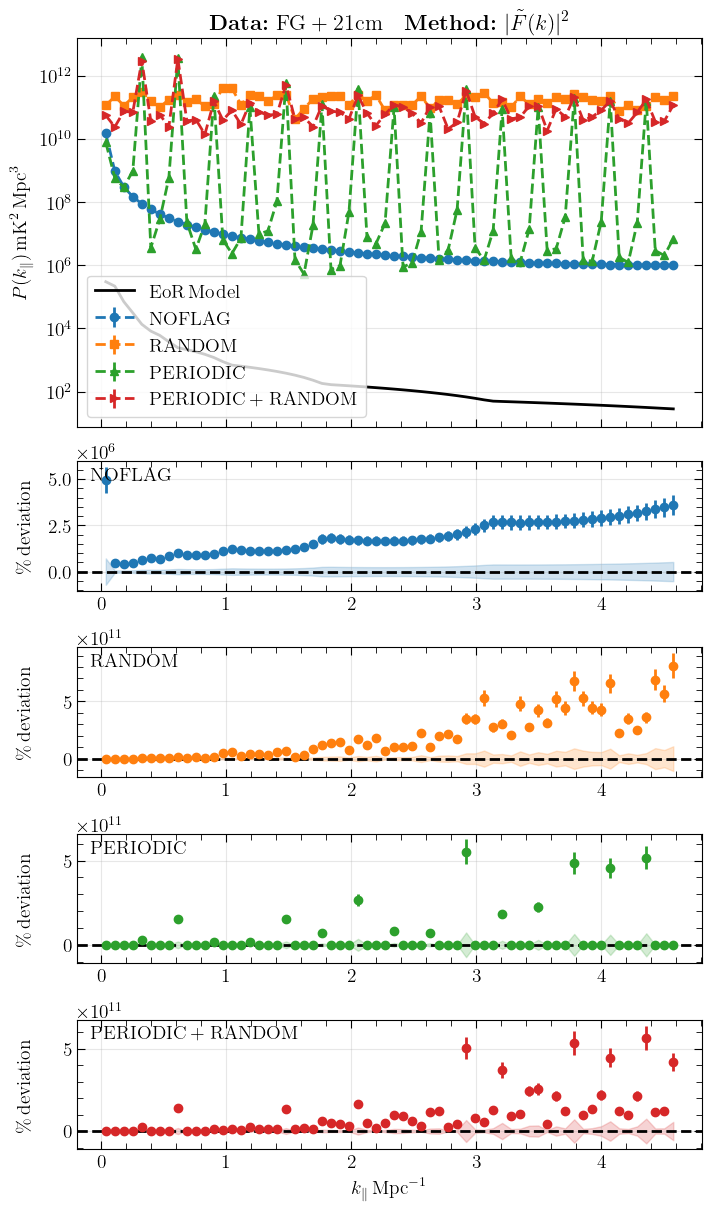

In [2]:
# --------------------------------------------------
# USER INPUTS
# --------------------------------------------------
path       = "results"
inp_signal = "FG+21cm"
SCF        = "None"

modes  = ['NOFLAG', 'RANDOM', 'PERIODIC', 'PERIODIC+RANDOM']
colors = ['C0', 'C1', 'C2', 'C3']
fmts = ['o', 's', '^', '>']

shift = 1.0
ylim  = None     # set to None if you do not want clipping
band = True

figname = f"plots/fft_Data_{inp_signal}_SCF_{SCF}_allflags.pdf"
os.makedirs("plots", exist_ok=True)

# --------------------------------------------------
# FIGURE LAYOUT
# --------------------------------------------------
fig = plt.figure(figsize=(7, 12))
gs  = fig.add_gridspec(
    5, 1,
    height_ratios=[3, 1, 1, 1, 1],
    hspace=0.07
)

ax1 = fig.add_subplot(gs[0])
axd = [fig.add_subplot(gs[i], sharex=ax1) for i in range(1, 5)]

# --------------------------------------------------
# LOOP OVER FLAG PATTERNS
# --------------------------------------------------
for i, (mode, color, fmt) in enumerate(zip(modes, colors, fmts)):

    # ---------- Load data ----------
    data = np.load(
        f"{path}/fft_inp_signal-{inp_signal}_flag-{mode}_SCF-{SCF}.npz"
    )

    kb_fft        = data["kb"]
    mean_fft      = data["mean"]
    err_fft       = data["err"]
    binned_th_fft = data["binned_th"]

    inp_signal1 = data["inp_signal"].tolist()
    flag1       = data["flag"].tolist()
    scf1        = data["SCF"].tolist()

    print(f"inp_signal = {inp_signal1}, flag = {flag1}, scf = {scf1}")

    # ---------- TOP PANEL: power spectra ----------
    ax1.errorbar(
        kb_fft,
        mean_fft * shift,
        err_fft * shift,
        fmt=fmt,
        ls='--',
        color=color,
        label=fr"$\rm{{ {mode} }}$"
    )


    if i == 0:
        ax1.plot(
            kb_fft,
            binned_th_fft * shift,
            '-k',
            lw=2,
            label=r'${\rm EoR\,Model}$'
        )

    # ---------- Deviation ----------
    ratio = 100.0 * (mean_fft / binned_th_fft - 1.0)
    err_r = 100.0 * err_fft / binned_th_fft

    axd[i].errorbar(
        kb_fft,
        ratio,
        err_r,
        fmt='o',
        color=color
    )

    if band:
        axd[i].fill_between(kb_fft, -err_r, err_r,
                            color=color, alpha=0.2,
                            label="_nolegend_")

    axd[i].axhline(0, color='k', ls='--')
    axd[i].grid(alpha=0.3)
    axd[i].set_ylabel(r'\rm{\%\,deviation}')

    axd[i].text(
        0.02, 0.85,
        fr"$\rm{{ {mode} }}$",
        transform=axd[i].transAxes,
        # fontsize=10
    )

    if ylim is not None:
        axd[i].set_ylim(-ylim, ylim)

# --------------------------------------------------
# FINAL FORMATTING
# --------------------------------------------------
ax1.set_yscale('log')
ax1.set_ylabel(r'$P(k_\parallel)\,{\rm mK}^2\,{\rm Mpc}^3$')
ax1.grid(alpha=0.3)
ax1.legend()
ax1.tick_params(labelbottom=False)

axd[-1].set_xlabel(r'$k_\parallel\,{\rm Mpc}^{-1}$')

ax1.set_title(
    r"\rm{{\bf Data:}~}" + fr"$\mathrm{{{inp_signal}}}$"
    + r"\rm{\quad {\bf Method:}~}" + r'$|\tilde{F}(k)|^2$',
    
)

fig.align_ylabels()
fig.savefig(figname, bbox_inches='tight')
print("Saved:", figname)


inp_signal = FG+21cm, flag = NOFLAG, scf = None
inp_signal = FG+21cm, flag = RANDOM, scf = None
inp_signal = FG+21cm, flag = PERIODIC, scf = None
inp_signal = FG+21cm, flag = PERIODIC+RANDOM, scf = None
Saved: plots/dct_Data_FG+21cm_SCF_None_allflags.pdf


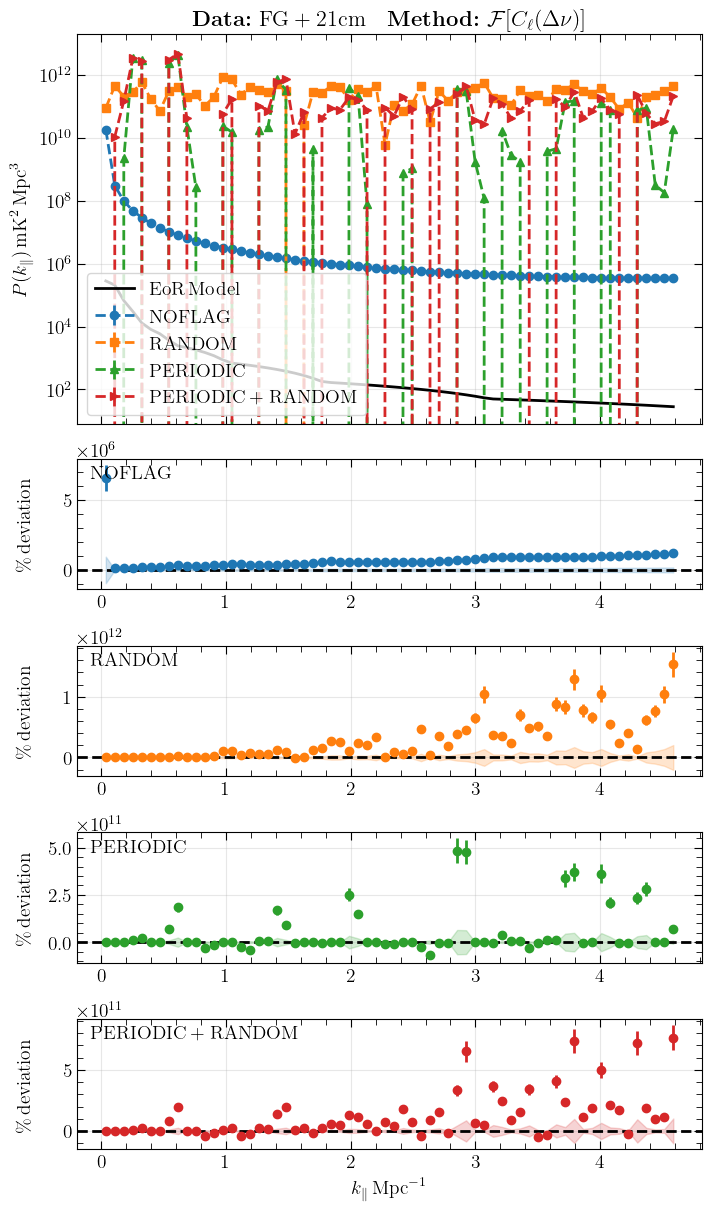

In [3]:
# --------------------------------------------------
# USER INPUTS
# --------------------------------------------------
path       = "results"
inp_signal = "FG+21cm"
SCF        = "None"

modes  = ['NOFLAG', 'RANDOM', 'PERIODIC', 'PERIODIC+RANDOM']
colors = ['C0', 'C1', 'C2', 'C3']
fmts = ['o', 's', '^', '>']

shift = 1.0
ylim  = None     # set to None if you do not want clipping
band = True

figname = f"plots/dct_Data_{inp_signal}_SCF_{SCF}_allflags.pdf"
os.makedirs("plots", exist_ok=True)

# --------------------------------------------------
# FIGURE LAYOUT
# --------------------------------------------------
fig = plt.figure(figsize=(7, 12))
gs  = fig.add_gridspec(
    5, 1,
    height_ratios=[3, 1, 1, 1, 1],
    hspace=0.07
)

ax1 = fig.add_subplot(gs[0])
axd = [fig.add_subplot(gs[i], sharex=ax1) for i in range(1, 5)]

# --------------------------------------------------
# LOOP OVER FLAG PATTERNS
# --------------------------------------------------
for i, (mode, color, fmt) in enumerate(zip(modes, colors, fmts)):

    # ---------- Load data ----------
    data = np.load(
        f"{path}/dct_inp_signal-{inp_signal}_flag-{mode}_SCF-{SCF}.npz"
    )

    kb_fft        = data["kb"]
    mean_fft      = data["mean"]
    err_fft       = data["err"]
    binned_th_fft = data["binned_th"]

    inp_signal1 = data["inp_signal"].tolist()
    flag1       = data["flag"].tolist()
    scf1        = data["SCF"].tolist()

    print(f"inp_signal = {inp_signal1}, flag = {flag1}, scf = {scf1}")

    # ---------- TOP PANEL: power spectra ----------
    ax1.errorbar(
        kb_fft,
        mean_fft * shift,
        err_fft * shift,
        fmt=fmt,
        ls='--',
        color=color,
        label=fr"$\rm{{ {mode} }}$"
    )


    if i == 0:
        ax1.plot(
            kb_fft,
            binned_th_fft * shift,
            '-k',
            lw=2,
            label=r'${\rm EoR\,Model}$'
        )

    # ---------- Deviation ----------
    ratio = 100.0 * (mean_fft / binned_th_fft - 1.0)
    err_r = 100.0 * err_fft / binned_th_fft

    axd[i].errorbar(
        kb_fft,
        ratio,
        err_r,
        fmt='o',
        color=color
    )

    if band:
        axd[i].fill_between(kb_fft, -err_r, err_r,
                            color=color, alpha=0.2,
                            label="_nolegend_")

    axd[i].axhline(0, color='k', ls='--')
    axd[i].grid(alpha=0.3)
    axd[i].set_ylabel(r'\rm{\%\,deviation}')

    axd[i].text(
        0.02, 0.85,
        fr"$\rm{{ {mode} }}$",
        transform=axd[i].transAxes,
        # fontsize=10
    )

    if ylim is not None:
        axd[i].set_ylim(-ylim, ylim)

# --------------------------------------------------
# FINAL FORMATTING
# --------------------------------------------------
ax1.set_yscale('log')
ax1.set_ylabel(r'$P(k_\parallel)\,{\rm mK}^2\,{\rm Mpc}^3$')
ax1.grid(alpha=0.3)
ax1.legend()
ax1.tick_params(labelbottom=False)

axd[-1].set_xlabel(r'$k_\parallel\,{\rm Mpc}^{-1}$')

ax1.set_title(
    r"\rm{{\bf Data:}~}" + fr"$\mathrm{{{inp_signal}}}$"
    + r"\rm{\quad {\bf Method:}~}" + r'${ \mathcal{F} [ C_\ell(\Delta\nu) ] }$',
    
)

fig.align_ylabels()
fig.savefig(figname, bbox_inches='tight')
print("Saved:", figname)
